In [66]:
!apt-get update
!apt-get install -y libreoffice
!pip install PyPDF2 python-docx nltk wordcloud

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,459 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libreoffice is already the newest version (1:7.3.7

In [67]:
import os
import pandas as pd
import numpy as np

from PyPDF2 import PdfReader
from docx import Document

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Exctracting the Text from Dataset**

In [68]:
import os
import subprocess

ROOT_DIR = "/content/drive/MyDrive/Resume_Classification_project/Resumes"

# converting doc to docx
for root, _, files in os.walk(ROOT_DIR):
    for file in files:
        if file.lower().endswith(".doc"):
            file_path = os.path.join(root, file)
            subprocess.run([
                "soffice", "--headless",
                "--convert-to", "docx",
                file_path,
                "--outdir", root
            ])

In [69]:
from PyPDF2 import PdfReader
from docx import Document

# coverting pdf to docx
def pdf_to_docx(pdf_path, docx_path):
    reader = PdfReader(pdf_path)
    doc = Document()

    for page in reader.pages:
        text = page.extract_text()
        if text:
            doc.add_paragraph(text)

    doc.save(docx_path)

In [70]:
for root, _, files in os.walk(ROOT_DIR):
    for file in files:
        if file.lower().endswith(".pdf"):
            pdf_path = os.path.join(root, file)
            docx_path = os.path.join(
                root,
                file.replace(".pdf", ".docx")
            )

            try:
                pdf_to_docx(pdf_path, docx_path)
            except Exception as e:
                print("Failed:", pdf_path, e)

# **Data Collection:**

In [71]:
import pandas as pd
from docx import Document

# Loading ALL Resumes
def read_docx(path):
    doc = Document(path)
    return " ".join(p.text for p in doc.paragraphs)



**Loding the Dataset in Dataframe**

In [72]:

data = []

for category in os.listdir(ROOT_DIR):
    category_path = os.path.join(ROOT_DIR, category)

    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.endswith(".docx"):
                file_path = os.path.join(category_path, file)
                text = read_docx(file_path)

                if len(text.strip()) > 0:
                    data.append({
                        "resume_text": text,
                        "Category": category
                    })


In [73]:
df = pd.DataFrame(data)
df.head()

,resume_text,Category
0,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer Lightning insight
1,resume R...,SQL Developer Lightning insight
2,Resu...,SQL Developer Lightning insight
3,Aradhana Tripathi Current Location: Gachibow...,SQL Developer Lightning insight
4,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer Lightning insight


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   resume_text  79 non-null     object
 1   Category     79 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.isnull().sum()

,0
resume_text,0
Category,0


In [77]:
df['Category'].value_counts()

,count
Category,
React Developer Resumes,24
workday resumes,21
Peoplesoft resumes,20
SQL Developer Lightning insight,14


/tmp/ipython-input-1851929180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


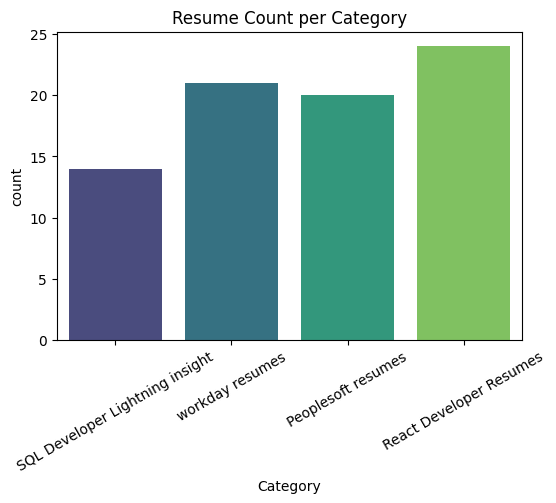

In [78]:
# Visualizing category distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=df, palette='viridis')
plt.xticks(rotation=30)
plt.title("Resume Count per Category")
plt.show()

**Resume Length Analysis**

In [79]:
df['word_count'] = df['resume_text'].apply(lambda x: len(x.split()))

df.groupby('Category')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Peoplesoft resumes,20.0,846.850000,625.311062,163.0,388.00,521.5,1078.50,2458.0
React Developer Resumes,24.0,330.625000,160.363937,19.0,205.75,331.5,400.75,786.0
SQL Developer Lightning insight,14.0,570.428571,241.608620,222.0,472.50,563.5,628.25,1115.0
workday resumes,21.0,791.142857,277.994116,343.0,571.00,787.0,893.00,1499.0


/tmp/ipython-input-3283840279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='word_count', data=df, palette='inferno' )


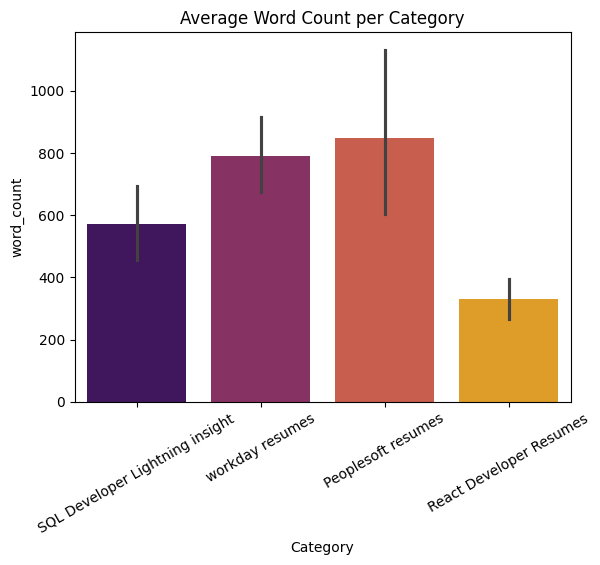

In [80]:
# Visualizing word count per category
sns.barplot(x='Category', y='word_count', data=df, palette='inferno' )
plt.xticks(rotation=30)
plt.title("Average Word Count per Category")
plt.show()

In [81]:
# Word count
df['word_count'] = df['resume_text'].apply(lambda x: len(x.split()))

# Character count
df['char_count'] = df['resume_text'].apply(len)

df[['word_count', 'char_count']].describe()

,word_count,char_count
count,79.000000,79.000000
mean,626.227848,4690.632911
std,423.819415,3125.599299
min,19.000000,162.000000
25%,350.500000,2740.000000
50%,515.000000,3708.000000
75%,800.500000,6156.500000
max,2458.000000,17654.000000


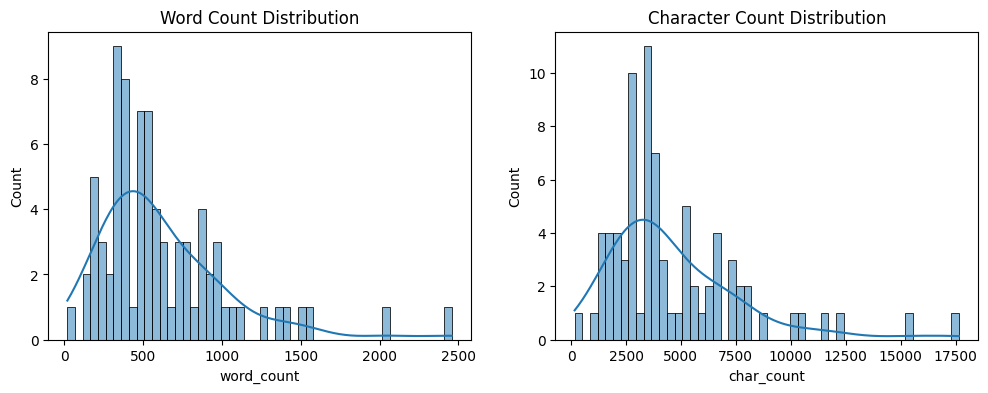

In [82]:
# Visualizing Word and character count
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution")

plt.subplot(1,2,2)
sns.histplot(df['char_count'], bins=50, kde=True)
plt.title("Character Count Distribution")

plt.show()

In [83]:
print("Total resumes:", df.shape[0])
print("Total categories:", df['Category'].nunique())

Total resumes: 79
Total categories: 4


# **Text Pre-processing**

In [84]:
df['resume_text'][0]

'ANIL KUMAR MADDUKURI  \t\t SQL & MSBI Developer     \t  Summary  2.4 years of experience in MS SQL Server (SSMS) and creating SSIS packages, SSRS Reports by using Microsoft Business Intelligence (MSBI) tools. Expertise in various types of Joins and Sub Queries for writing complex queries involving multiple tables. Handled data manipulation and data consistency by creating Views, Triggers, and Synonyms. Hands on experience in creation, optimization and debugging Stored Procedure and Functions. Familiar in writing queries using CTE, Temporary Tables and Table Variables. Good experience in using Set Operators like Union, Union All, Except and Intersect to assist required data. Experience in manipulate the data from multiple table and report to the client using Aggregate Functions, Windows Functions and String Functions. Worked extensively on Data Extraction, Transformation and Loading (ETL) process in SQL Server Integration Services. Used containers such as for each loop container and se

In [85]:
df['resume_text'][5]

'SQL DEVELOPER Name: -   Bandi prem sai   Willing to work under a challenging and professional environment with exposure to new Technologies as a T-SQL in the area of SQL SERVER 2012/2016 with Enterprise Portal and where there is ample scope for Organizational growth as well as individual growth.   2.6 years of experience in Microsoft SQL Server environment, with thorough knowledge of SQL Server 2012/2016 databases.  Expertise in scripting T-SQL queries, Stored Procedures, User Defined Functions and Triggers. Hands on experience in performing Error Handling and performance tuning in Stored Procedure. Good experienced in creating and using Temporary table, Table Variable and CTE’s (Common table Expressions) Used Sub-Queries, Derived table and Joins to simplify complex queries involving multiple tables. Expertise in creating, maintaining database objects like Indexes, Functions, views, UDF’s, constraints. Good experience in using Ranking Functions, Date Functions, String Functions and Ag

In [86]:
#text cleaning

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    # Remove emails, URLs, numbers, and special characters
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Removing stopwords, short words and applying lemmatization
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]

    # Joining tokens back into a string
    return " ".join(tokens)

In [87]:
df

,resume_text,Category,word_count,char_count
0,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer Lightning insight,626,4377
1,resume R...,SQL Developer Lightning insight,576,4085
2,Resu...,SQL Developer Lightning insight,629,4826
3,Aradhana Tripathi Current Location: Gachibow...,SQL Developer Lightning insight,714,5089
4,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer Lightning insight,530,3959
...,...,...,...,...
74,KAMBALA SAI SURENDRA \tMandepeta \t ...,React Developer Resumes,172,1568
75,PROFILE Searching for the opportunity to br...,React Developer Resumes,435,3366
76,CURRICULUM VITAE I hereby declare that the...,React Developer Resumes,19,162
77,\nPage | 1 \n Name: M. Prabakaran \nTitle...,React Developer Resumes,396,2863


In [88]:
df['cleaned_text'] = df['resume_text'].apply(clean_text)
df['cleaned_text'][0]

'anil kumar maddukuri sql msbi developer summary year experience sql server ssms creating ssis package ssrs report using microsoft business intelligence msbi tool expertise various type join sub query writing complex query involving multiple table handled data manipulation data consistency creating view trigger synonym hand experience creation optimization debugging stored procedure function familiar writing query using cte temporary table table variable good experience using set operator like union union except intersect assist required data experience manipulate data multiple table report client using aggregate function window function string function worked extensively data extraction transformation loading etl process sql server integration service used container loop container sequence container load data multiple source file database table expertise using task like data flow task execute sql task control flow task execute package task execute process task bulk insert task sends m

In [89]:
df

,resume_text,Category,word_count,char_count,cleaned_text
0,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer Lightning insight,626,4377,anil kumar maddukuri sql msbi developer summar...
1,resume R...,SQL Developer Lightning insight,576,4085,resume ramalakshmi career objective profession...
2,Resu...,SQL Developer Lightning insight,629,4826,resume name neeraj mishra year month experienc...
3,Aradhana Tripathi Current Location: Gachibow...,SQL Developer Lightning insight,714,5089,aradhana tripathi current location gachibowli ...
4,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer Lightning insight,530,3959,raju pavana kumari professional summary year p...
...,...,...,...,...,...
74,KAMBALA SAI SURENDRA \tMandepeta \t ...,React Developer Resumes,172,1568,kambala sai surendra mandepeta summary project...
75,PROFILE Searching for the opportunity to br...,React Developer Resumes,435,3366,profile searching opportunity bring year exper...
76,CURRICULUM VITAE I hereby declare that the...,React Developer Resumes,19,162,curriculum vitae hereby declare mentioned part...
77,\nPage | 1 \n Name: M. Prabakaran \nTitle...,React Developer Resumes,396,2863,page name prabakaran title developer professio...


In [90]:
# Most Common Words

all_words = [
    w
    for text in df['cleaned_text']
    for w in text.split()
]

Counter(all_words).most_common(20)

[('experience', 566),
 ('server', 476),
 ('application', 469),
 ('report', 448),
 ('peoplesoft', 395),
 ('using', 375),
 ('workday', 367),
 ('integration', 344),
 ('project', 326),
 ('data', 304),
 ('process', 280),
 ('database', 270),
 ('business', 256),
 ('sql', 234),
 ('system', 231),
 ('knowledge', 203),
 ('web', 203),
 ('requirement', 193),
 ('client', 191),
 ('tool', 189)]

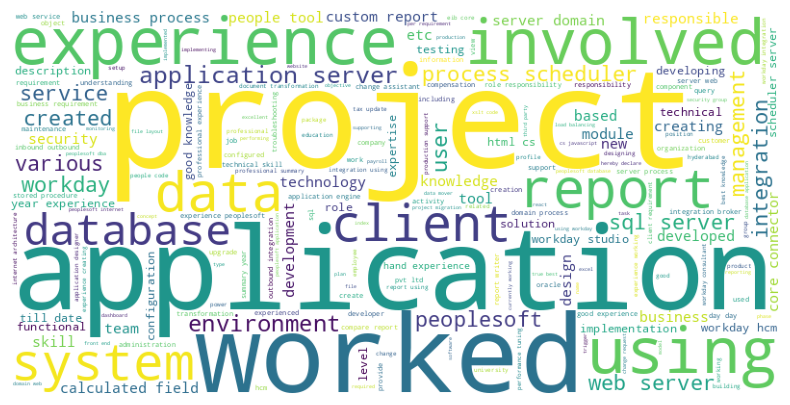

In [91]:
# WordCloud for most common words

wordcloud = WordCloud(width=800, height=400, background_color='white')\
            .generate(" ".join(all_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [92]:
for category in df['Category'].unique():
    print(f"\nTop words in {category}:")

    words = " ".join(
        df[df['Category'] == category]['cleaned_text']
    ).split()

    print(Counter(words).most_common(10))



Top words in SQL Developer Lightning insight:
[('sql', 197), ('data', 111), ('experience', 98), ('server', 96), ('using', 79), ('table', 75), ('report', 73), ('database', 64), ('query', 62), ('function', 59)]

Top words in workday resumes:
[('workday', 367), ('integration', 274), ('report', 266), ('business', 176), ('experience', 160), ('using', 144), ('process', 123), ('eib', 123), ('worked', 108), ('system', 108)]

Top words in Peoplesoft resumes:
[('server', 375), ('peoplesoft', 369), ('application', 341), ('experience', 225), ('database', 187), ('process', 144), ('environment', 125), ('project', 119), ('domain', 112), ('people', 111)]

Top words in React Developer Resumes:
[('react', 126), ('experience', 83), ('html', 76), ('using', 76), ('project', 76), ('cs', 66), ('application', 58), ('knowledge', 57), ('web', 56), ('javascript', 55)]


In [93]:
# function for Category wise Word Cloud
def plot_category_wordcloud(category_name):
    text = " ".join(
        df[df['Category'] == category_name]['cleaned_text']
    )

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {category_name}")
    plt.show()

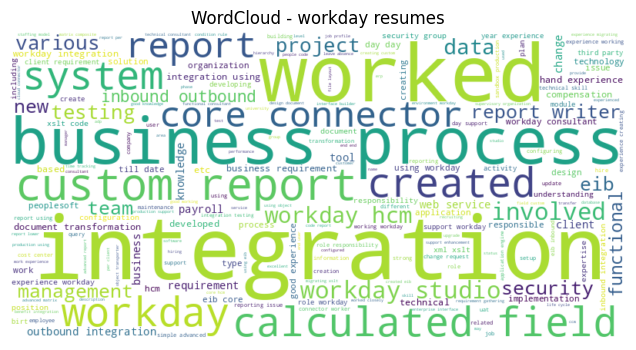

In [94]:
plot_category_wordcloud('workday resumes')

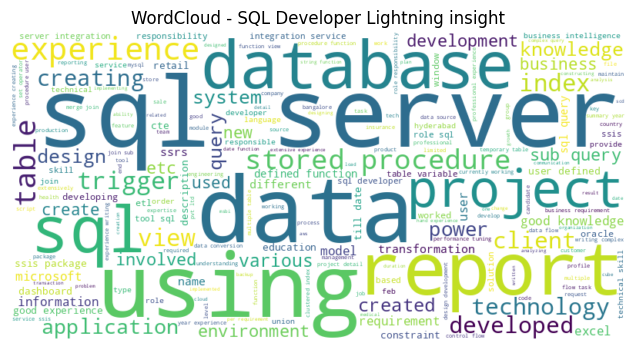

In [95]:
plot_category_wordcloud('SQL Developer Lightning insight')

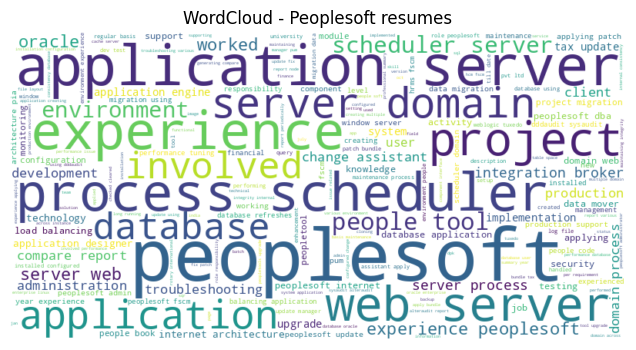

In [96]:
plot_category_wordcloud('Peoplesoft resumes')

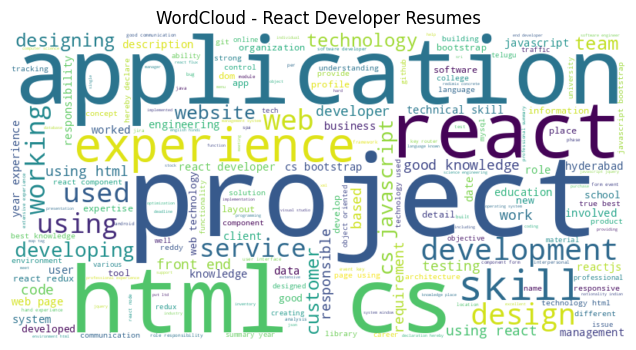

In [97]:
plot_category_wordcloud('React Developer Resumes')

In [98]:
df


,resume_text,Category,word_count,char_count,cleaned_text
0,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer Lightning insight,626,4377,anil kumar maddukuri sql msbi developer summar...
1,resume R...,SQL Developer Lightning insight,576,4085,resume ramalakshmi career objective profession...
2,Resu...,SQL Developer Lightning insight,629,4826,resume name neeraj mishra year month experienc...
3,Aradhana Tripathi Current Location: Gachibow...,SQL Developer Lightning insight,714,5089,aradhana tripathi current location gachibowli ...
4,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer Lightning insight,530,3959,raju pavana kumari professional summary year p...
...,...,...,...,...,...
74,KAMBALA SAI SURENDRA \tMandepeta \t ...,React Developer Resumes,172,1568,kambala sai surendra mandepeta summary project...
75,PROFILE Searching for the opportunity to br...,React Developer Resumes,435,3366,profile searching opportunity bring year exper...
76,CURRICULUM VITAE I hereby declare that the...,React Developer Resumes,19,162,curriculum vitae hereby declare mentioned part...
77,\nPage | 1 \n Name: M. Prabakaran \nTitle...,React Developer Resumes,396,2863,page name prabakaran title developer professio...


# **Text Representation:**
**TF-IDF**

In [100]:
# Unigram

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_uni = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=3000
)

X_uni = tfidf_uni.fit_transform(df['cleaned_text'])

In [105]:
print(tfidf_uni.get_feature_names_out()[:20])

['abdul' 'ability' 'absence' 'abstract' 'abstraction' 'ac' 'academic'
 'accenture' 'accept' 'acceptable' 'acceptance' 'access' 'accessibility'
 'accessible' 'accessing' 'accessory' 'acclimatize' 'accommodate'
 'accomplish' 'according']


In [106]:
# Bigram (2-word phrases)

tfidf_bi = TfidfVectorizer(
    ngram_range=(2,2),
    max_features=3000
)

X_bi = tfidf_bi.fit_transform(df['cleaned_text'])
print(tfidf_bi.get_feature_names_out()[:20])

['abdul sharuk' 'ability learn' 'ability work' 'absence condition'
 'absence delta' 'absence management' 'absence module'
 'absence recruiting' 'academic percentage' 'acceptable level'
 'acceptance testing' 'access people' 'according business'
 'according change' 'account information' 'account maintain'
 'account payable' 'account provisioning' 'achieve organizational'
 'across instance']


In [107]:
# Trigram (3-word phrases)

tfidf_tri = TfidfVectorizer(
    ngram_range=(3,3),
    max_features=3000
)

X_tri = tfidf_tri.fit_transform(df['cleaned_text'])
print(tfidf_tri.get_feature_names_out()[:20])

['ability work team' 'absence condition rule' 'absence delta change'
 'acceptable level status' 'access people book' 'according change request'
 'account information cost' 'account maintain workflow'
 'account provisioning integration' 'across instance monitor'
 'across instance troubleshooting' 'active production support'
 'activity checking cleaning' 'activity involved creating'
 'adding feature performed' 'adding new xslt' 'adding value business'
 'additionally also involved' 'addm report analyzing'
 'admin peoplesoft dba']


In [102]:
# Combine Uni + Bi-grams

tfidf = TfidfVectorizer(
    ngram_range=(1,2),   # unigram + bigram
    max_features=5000
)

X = tfidf.fit_transform(df['cleaned_text'])
y = df['Category']


In [103]:
print(tfidf.get_feature_names_out()[:20])

['abdul' 'ability' 'ability work' 'absence' 'absence condition'
 'absence delta' 'absence management' 'absence module'
 'absence recruiting' 'absence recuring' 'absence time' 'abstract'
 'academic' 'academic percentage' 'academic project'
 'academic qualification' 'accenture' 'accenture hyderabad' 'acceptable'
 'acceptable level']
